# The Naylor Model — Master Notebook

Base-stealing intelligence for slow-but-elite stealers (the *Josh Naylor* trait: a runner who
steals better than ~99% of MLB without the wheels). This notebook runs the model end-to-end.

**Runs without network** — it reads the cached feature data (`Naylor_Model_Data.csv`) and the
tuned hyperparameters, refits Model B, and rebuilds the report. The full Statcast data pull lives in
`scripts/v7_explore.py` (network-bound) and is *not* required here.

| Section | What |
|---|---|
| 1 | Data — the runner-season master |
| 2 | SSSI — Slow-Steal Skill Index leaderboard |
| 3 | Model B — season-level Bayesian-tuned **XGBoost** (AUC by era) |
| 4 | GLM — the steal-success equation |
| 5 | xSB — speed-vs-production quadrant |
| 6 | **Model A — per-attempt XGBoost (AUC ~0.74)** |
| 7 | Benchmark & tuning recap |
| 8 | Build the v8 report |


## Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path().resolve()
while not (ROOT / "Figures").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
SCRIPTS = ROOT / "scripts"
DATA    = ROOT / "data"
FIGS    = ROOT / "Figures"
sys.path.insert(0, str(SCRIPTS))
print("Repo root:", ROOT)


Repo root: /Users/shunchen/Desktop/The-Naylor-Model


## 1 — Data: the runner-season master

`Naylor_Model_Data.csv` is the curated master — one row per qualified runner-season with every
feature plus the SSSI ranking. (`data/` holds the full working set the pipeline reads.)

In [2]:
data = pd.read_csv(ROOT / "Naylor_Model_Data.csv")
print(f"{len(data)} runner-seasons × {data.shape[1]} columns")
data[["player_name", "season", "sprint_speed", "jump_time", "lead_gain",
      "real_sb_pct", "sb_attempts"]].head()


673 runner-seasons × 66 columns


,player_name,season,sprint_speed,jump_time,lead_gain,real_sb_pct,sb_attempts
0,Josh Naylor,2025,24.4,1.87,3.874474,0.915915,32
1,Josh Naylor,2026,24.6,1.84,3.874474,0.836256,14
2,Freddie Freeman,2024,25.8,1.81,4.331902,0.805554,11
3,Christian Vázquez,2021,25.2,1.93,3.762556,0.699345,12
4,Juan Soto,2025,25.8,1.85,3.112091,0.891253,42


## 2 — SSSI: Slow-Steal Skill Index

A weighted composite that surfaces the Naylor/Soto archetype — elite-performing slow runners.
Naylor and Soto were held out when the weights were fit, so their ranking is genuinely out-of-sample.

In [3]:
sssi_col = next((c for c in data.columns if c.lower().startswith("sssi")), None)
top = data.sort_values(sssi_col, ascending=False).head(15)
top[["player_name", "season", "sprint_speed", "real_sb_pct", sssi_col]].reset_index(drop=True)


,player_name,season,sprint_speed,real_sb_pct,SSSI_v7
0,Josh Naylor,2025,24.4,0.915915,1.850796
1,Josh Naylor,2026,24.6,0.836256,1.683072
2,Freddie Freeman,2024,25.8,0.805554,1.230985
3,Christian Vázquez,2021,25.2,0.699345,1.188515
4,Juan Soto,2025,25.8,0.891253,1.179133
5,Kyle Schwarber,2025,25.9,0.816992,1.149561
6,Miguel Rojas,2024,25.8,0.792591,1.116415
7,Kyle Tucker,2024,26.0,0.930554,1.105821
8,Manny Machado,2024,25.8,0.827159,1.086801
9,Alec Burleson,2024,25.5,0.716048,1.083320


## 3 — Model B: Bayesian-tuned XGBoost

Model B predicts season steal success. v8 upgraded it from a gradient-boosting classifier to a
**Bayesian-tuned XGBoost** (Optuna, 100 trials). `model_xgb.main()` refits it on the cached features
(no network), recomputes AUC by era, and refreshes the AUC + importance figures.

In [4]:
import model_xgb
auc_rows = model_xgb.main()
pd.DataFrame(auc_rows)


data_dir = /Users/shunchen/Desktop/The-Naylor-Model/data
  rows=673  features=18  league_sb=0.793


        full  n= 673  AUC=0.6244


    pre_2023  n= 265  AUC=0.6046


   post_2023  n= 408  AUC=0.6647


model_xgb: wrote AUC + importance CSVs, refreshed figures, and curated root CSVs.


,epoch,n,auc
0,full,673,0.6244
1,pre_2023,265,0.6046
2,post_2023,408,0.6647


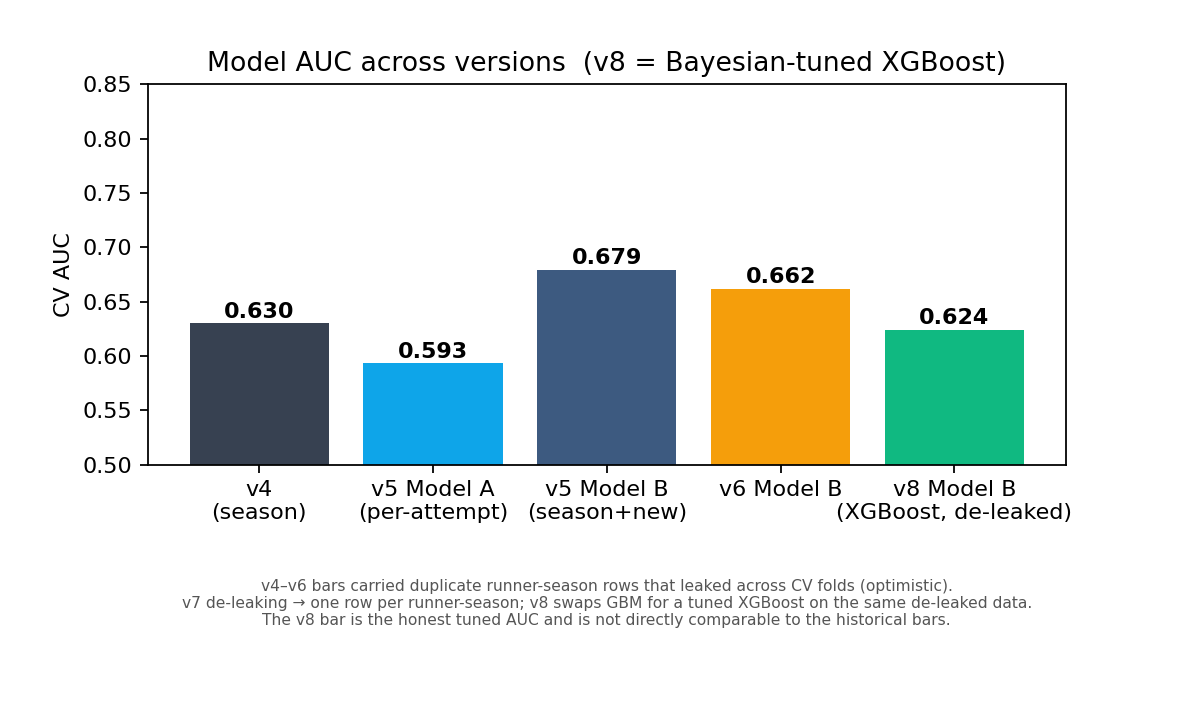

In [5]:
display(Image(filename=str(FIGS / "Fig_v7_AUC.png")))


## 4 — GLM: the steal-success equation

The interpretable model. Each lever's weight is reported as the change in steal-success rate for a
+1-SD improvement — the basis for the report's equation figure and coaching levers.

,feature,feature_raw,league_avg,one_tier_step,sb_pct_boost_per_tier,odds_multiplier,tech_coefficient,higher_is_better
0,Post-Release Distance,avg_post_release_distance,52.205,2.916,24.76,3.994,1.3847,True
1,Jump Time,jump_time,1.768,0.043,17.32,2.345,0.8524,False
2,Avg Catcher Pop Faced,avg_pop_faced,1.962,0.036,-12.13,0.610,-0.4945,True
3,Accel Gap,accel_gap,-1.405,18.951,9.94,1.570,0.4513,True
4,Sprint Speed (capped at 28),speed_capped,27.709,0.553,-6.61,0.761,-0.2727,True
5,Avg Pitcher Pickoff Rate Faced,avg_pickoff_rate_faced,0.011,0.010,4.46,1.214,0.1941,False
6,Two-Strike Count Share,two_strike_share,0.862,0.208,4.16,1.198,0.1807,False
7,Primary Lead,primary_lead,11.810,0.826,-4.02,0.846,-0.1675,True
8,Share vs Weak-Arm Catchers,weak_arm_share,0.265,0.315,2.51,1.114,0.1080,True
9,Lead Gain (jerk),lead_gain,3.730,0.791,2.08,1.093,0.0891,True


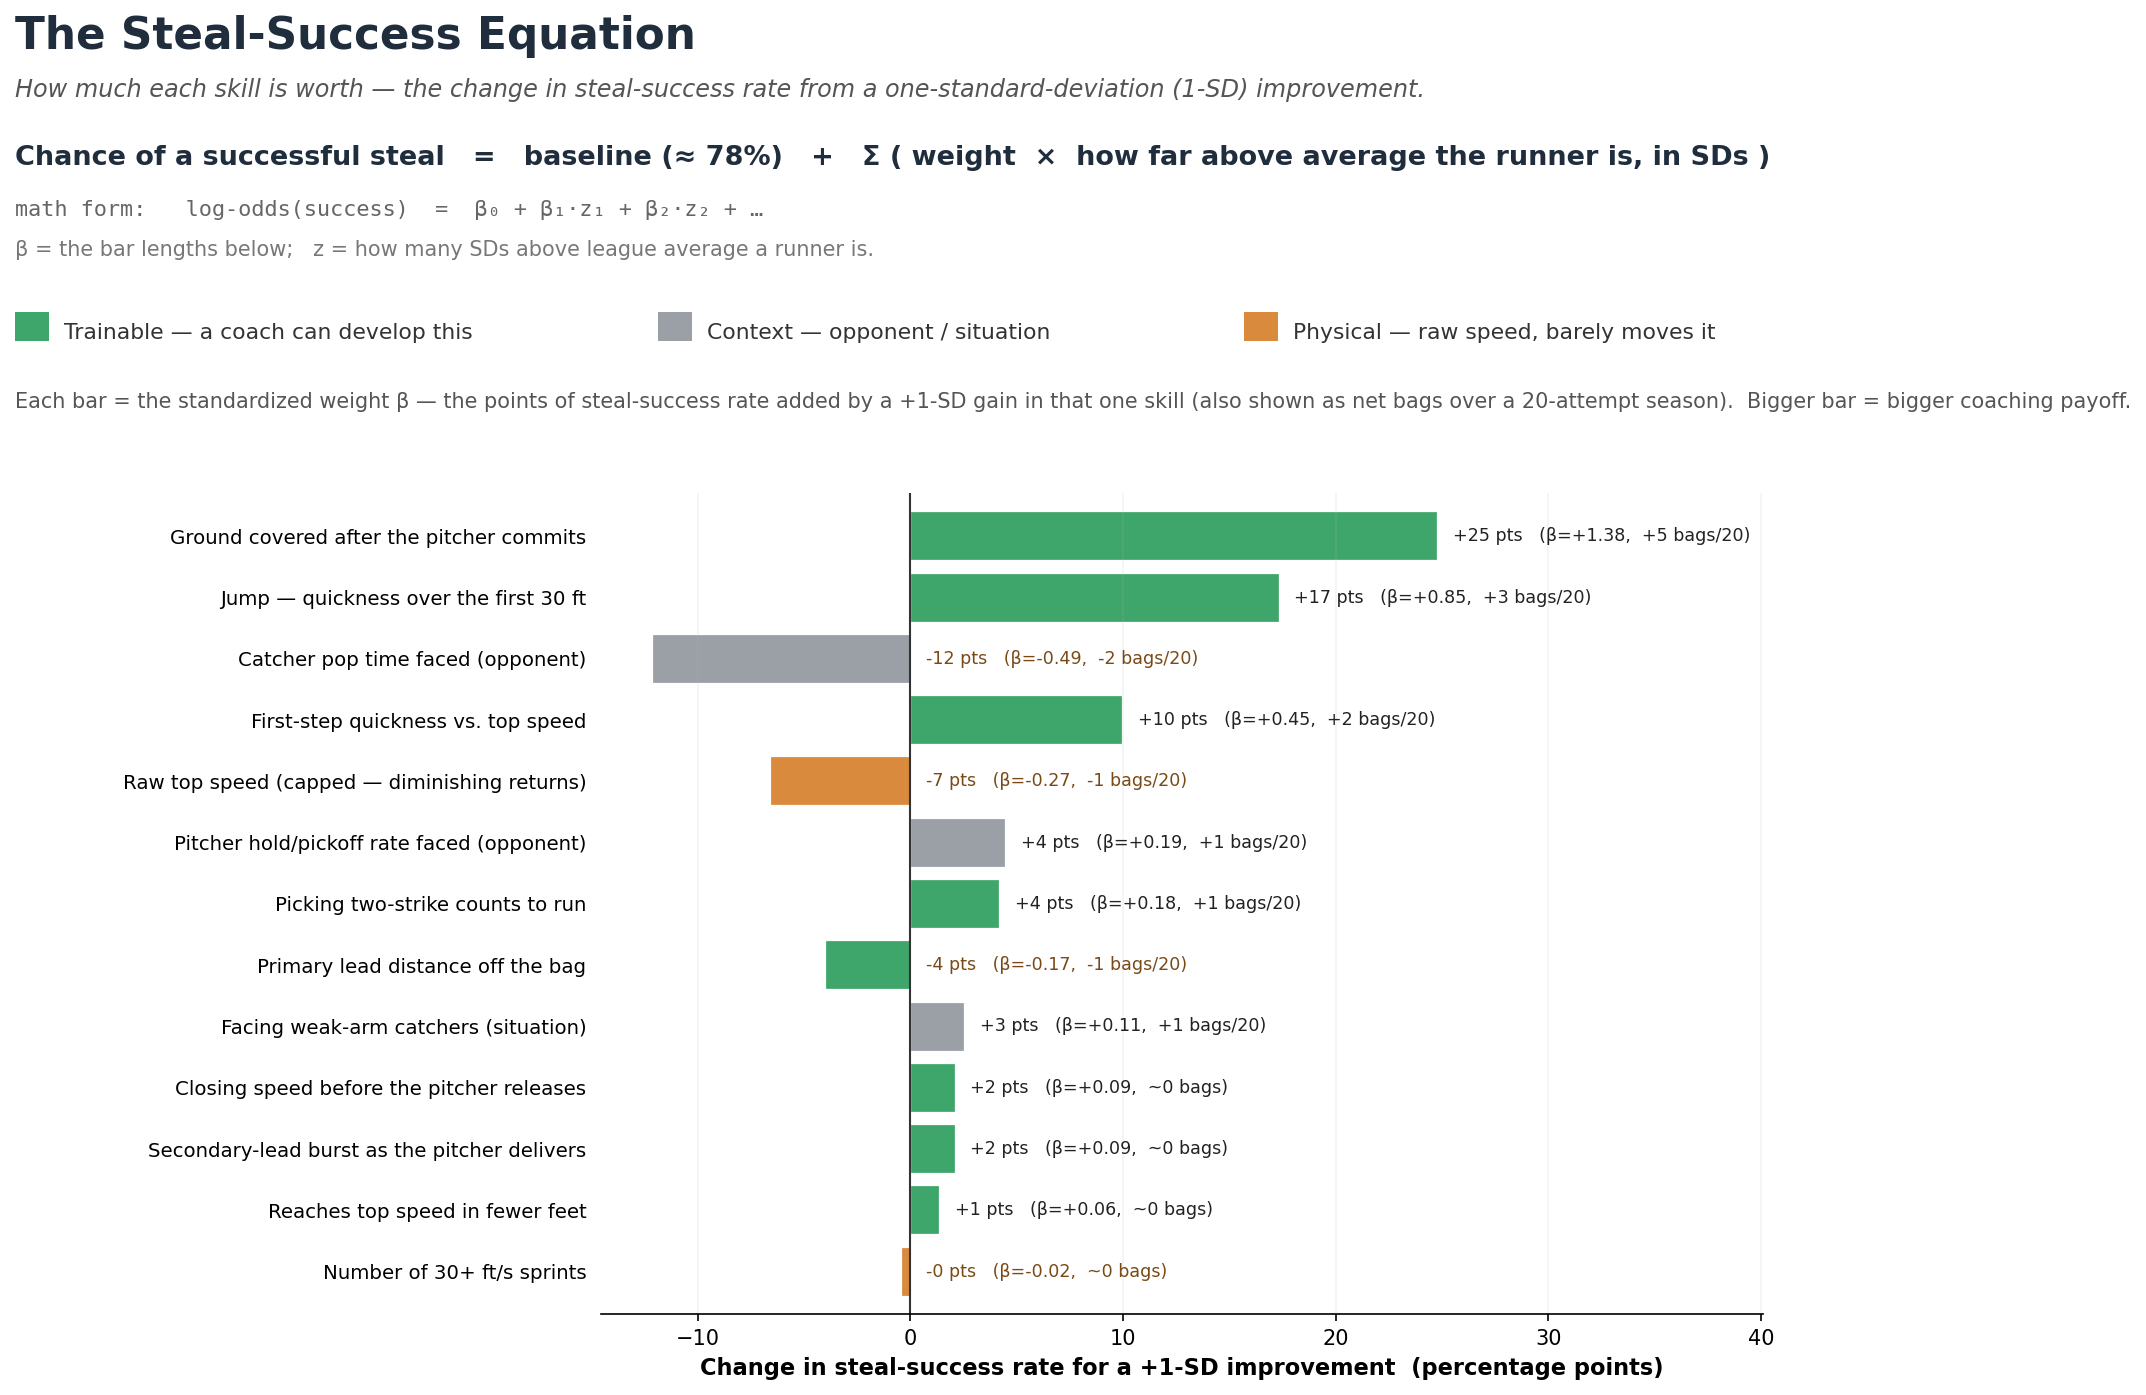

In [6]:
glm = pd.read_csv(DATA / "DF_v7_GLM_PlainEnglish.csv")
display(glm)
display(Image(filename=str(FIGS / "Fig_v8_Equation.png")))


## 5 — xSB: speed-vs-production quadrant

A descriptive lens splitting the league into Realized Burners, Untapped Wheels, Crafty Technicians
(the Naylor/Soto archetype), and Stationary runners.

quadrant
Stationary           444
Untapped Wheels      350
Realized Burner      339
Crafty Technician    167
Name: count, dtype: int64


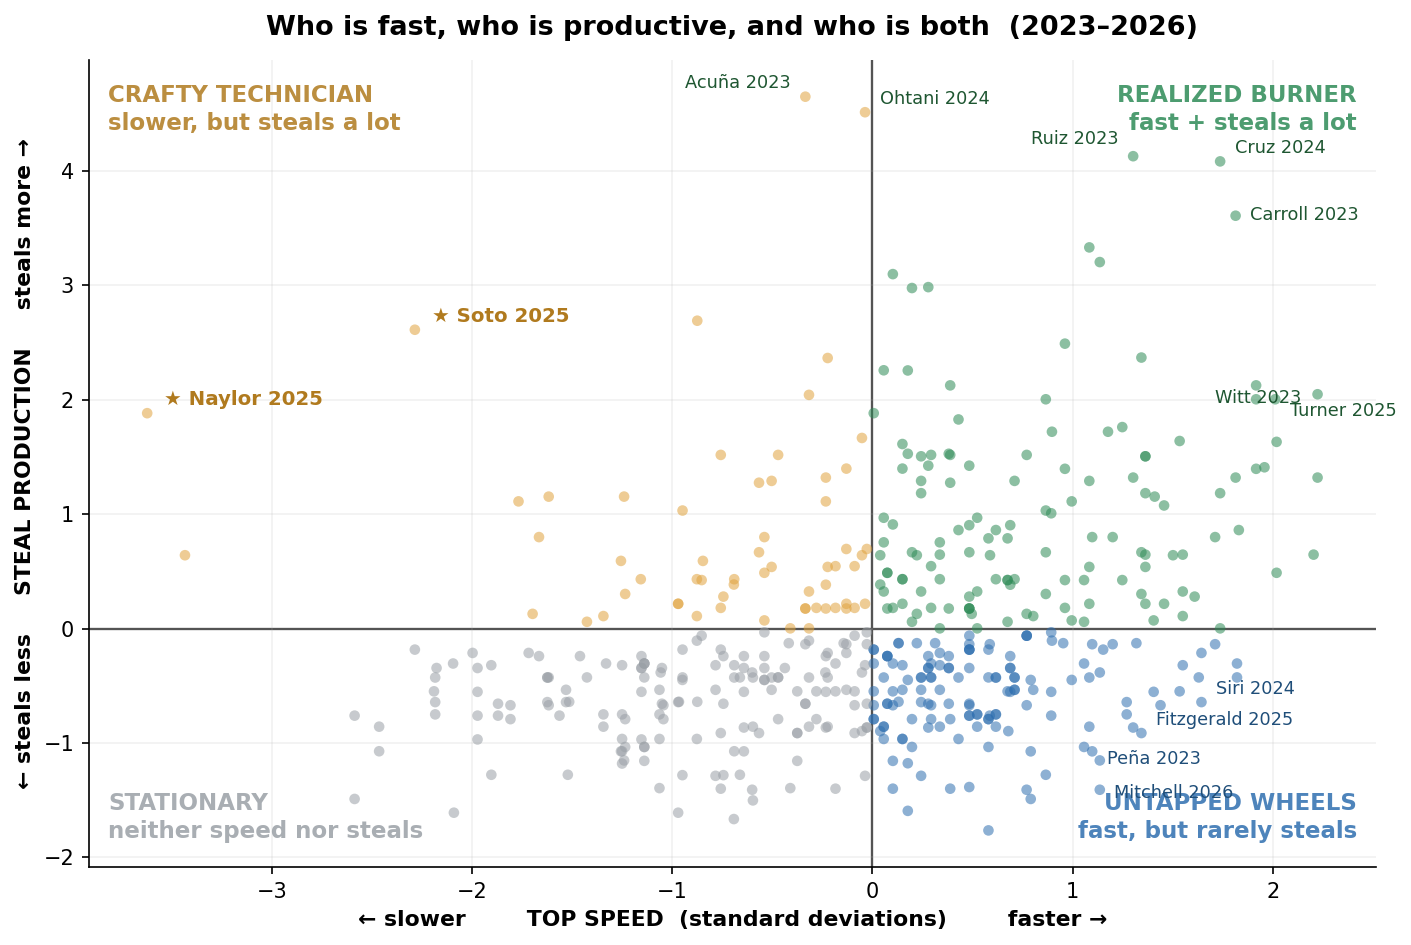

In [7]:
xsb = pd.read_csv(DATA / "DF_v7_xSB_Outcome.csv")
print(xsb["quadrant"].value_counts())
display(Image(filename=str(FIGS / "Fig_v8_xSB_Quadrant.png")))


## 6 — Per-attempt model (Model A) — the AUC jump

The season model tops out near 0.62 on 673 rows. Modeling the **~10,400 individual tracked attempts**
(Statcast leads cache) instead lifts CV AUC to **~0.74** — the per-pitch lead distances are what
decide a steal. Leakage-checked; deep learning is *not* used (gradient boosting wins on tabular data
this size).

In [8]:
import model_perattempt
pa = model_perattempt.main()
display(pa)


attempts: 10366  (SB 8405 / CS 1961, rate 0.811)

Per-attempt SB-success model (5-fold stratified CV, pooled OOF AUC):


  leads + base + runner skill                      AUC = 0.7387


  + catcher & pitcher tendency (OOF target-encoded) AUC = 0.7231

wrote /Users/shunchen/Desktop/The-Naylor-Model/data/DF_perattempt_AUC.csv


,model,auc
0,per-attempt: leads+base+runner,0.7387
1,per-attempt: + catcher/pitcher (OOF),0.7231
2,"season Model B (XGBoost, for reference)",0.6244


## 7 — Benchmark & tuning recap

Six season-level classifiers compared on the same de-leaked data, plus the tuned XGBoost params.

In [9]:
bench = pd.read_csv(DATA / "DF_benchmark_AUC.csv")
display(bench.sort_values("auc", ascending=False).reset_index(drop=True))
params = pd.read_csv(DATA / "DF_xgb_tuned_params.csv")
display(params.T)


,model,auc,vs_baseline
0,XGBoost,0.6159,0.0155
1,CatBoost,0.6016,0.0012
2,GBM (sklearn) — baseline,0.6004,0.0000
3,Random Forest,0.5872,-0.0132
4,Logistic Regression (L2),0.5785,-0.0219
5,GAM (LogisticGAM),0.5650,-0.0354


,0
max_depth,6.000000
min_child_weight,14.674636
gamma,0.173946
n_estimators,850.000000
learning_rate,0.010099
subsample,0.641398
colsample_bytree,0.776772
colsample_bylevel,0.540192
reg_alpha,0.078924
reg_lambda,0.000566


## 8 — Build the v8 report

Regenerates the applied main report (repo root) and the Technical Appendix (`Reports/`). Reads the
data refreshed above — no network.

In [10]:
import importlib.util, subprocess
if importlib.util.find_spec("docx") is None:
    print("python-docx is not installed in this kernel — skipping the in-notebook build.")
    print("Run it from the project environment:  python3 scripts/build_v8_report.py")
else:
    r = subprocess.run([sys.executable, str(SCRIPTS / "build_v8_report.py")],
                       capture_output=True, text=True)
    print(r.stdout[-1500:])
    if r.returncode != 0:
        print("STDERR:", r.stderr[-1500:])


python-docx is not installed in this kernel — skipping the in-notebook build.
Run it from the project environment:  python3 scripts/build_v8_report.py


---
### Next steps
See [`AUC_Roadmap.md`](AUC_Roadmap.md) for the prioritized plan to push AUC higher — the untapped
matchup variables (pitcher handedness, pitch type, count, catcher identity). To re-pull raw Statcast
data, run `python3 scripts/v7_explore.py` (requires network).